<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Customer_Churn_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
init_notebook_mode(connected=True)

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# setting display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [7]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Checking duplicated data
df.duplicated().any()

np.False_

In [10]:
# Checking missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
#  Check the count and what unique values exist for each feature
for col in df.columns:
    print(f"Column: {col}")
    print(f"Num unique: {cust[col].nunique()}")
    print("Unique values:", cust[col].unique())
    print("-" * 40)

Column: customerID
Num unique: 7043
Unique values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
----------------------------------------
Column: gender
Num unique: 2
Unique values: ['Female' 'Male']
----------------------------------------
Column: SeniorCitizen
Num unique: 2
Unique values: [0 1]
----------------------------------------
Column: Partner
Num unique: 2
Unique values: ['Yes' 'No']
----------------------------------------
Column: Dependents
Num unique: 2
Unique values: ['No' 'Yes']
----------------------------------------
Column: tenure
Num unique: 73
Unique values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
----------------------------------------
Column: PhoneService
Num unique: 2
Unique values: ['No' 'Yes']
----------------------------------------
Column:

In [12]:
# Mask for all columns
mask_empty_all = df.applymap(lambda x: isinstance(x, str) and x.strip() == '')

# Count of empty strings per column
empty_count_per_col = mask_empty_all.sum()

print("Number of empty strings per column:")
print(empty_count_per_col)

Number of empty strings per column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [13]:
df['TotalCharges'] = pd.to_numeric(cust['TotalCharges'], errors='coerce')

In [14]:
# Checking missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
# Fill NaN values only in the 'TotalCharges' column with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [16]:
# Checking missing values
df.isnull().any().sum()

np.int64(0)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
# Grouping Categorical and Numerical Columns
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [19]:
def hist_boxplot(df, cols):
    # Create a subplot with 2 rows (histogram, boxplot) and len(cols) columns
    fig, axes = plt.subplots(2, len(cols), figsize=(5 * len(cols), 8))

    for i, col in enumerate(cols):
        # Plot histogram with #9EBC8A
        sns.histplot(
            data=df, x=col, ax=axes[0, i], kde=True, color='#9EBC8A'
        )
        axes[0, i].set_title(f'Histogram of {col}', color='#537D5D')

        # Plot boxplot with #73946B
        sns.boxplot(
            data=df, x=col, ax=axes[1, i], color='#73946B'
        )
        axes[1, i].set_title(f'Boxplot of {col}', color='#537D5D')

    # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.show()

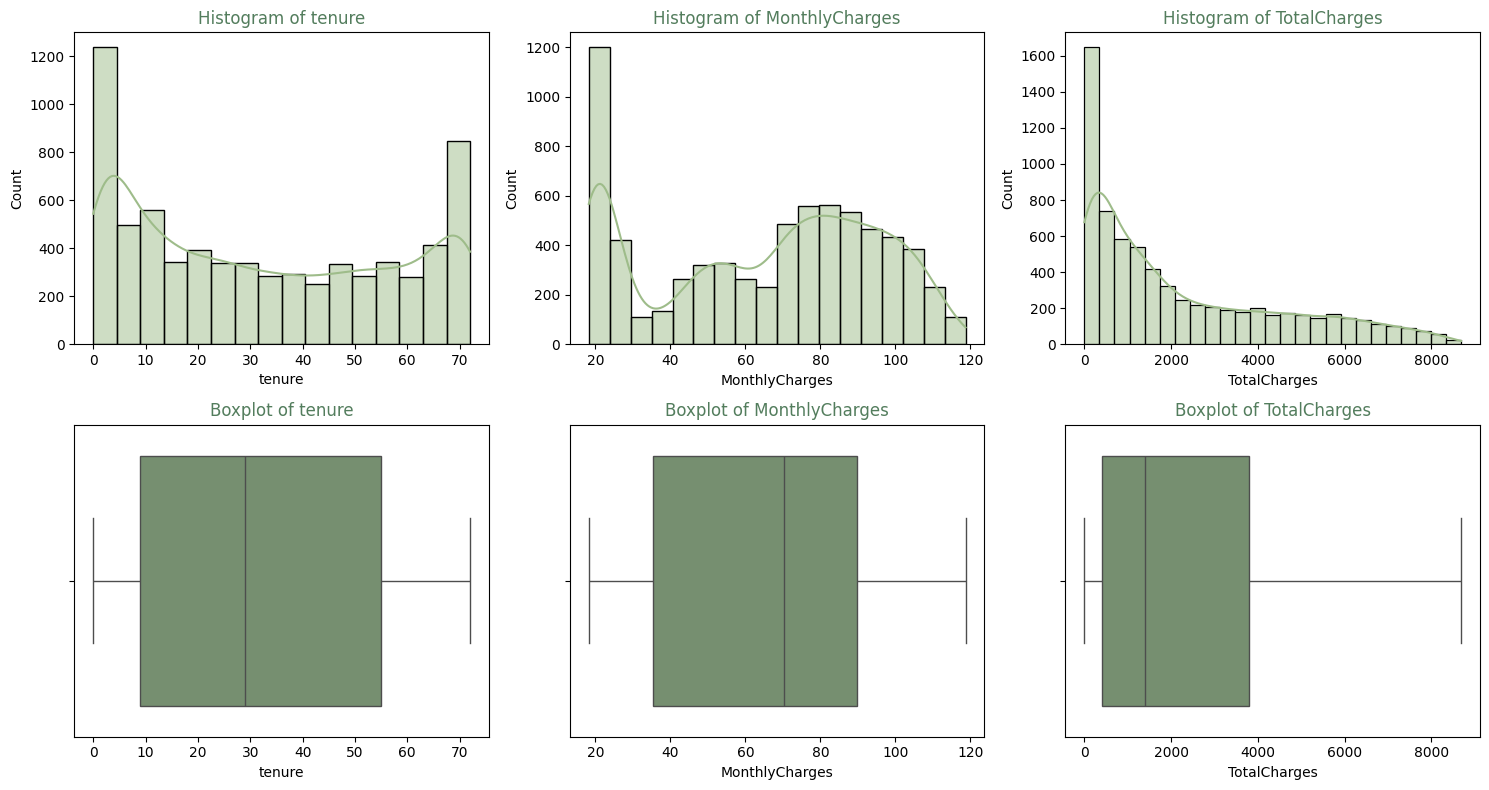

In [21]:
hist_boxplot(df, num_cols)

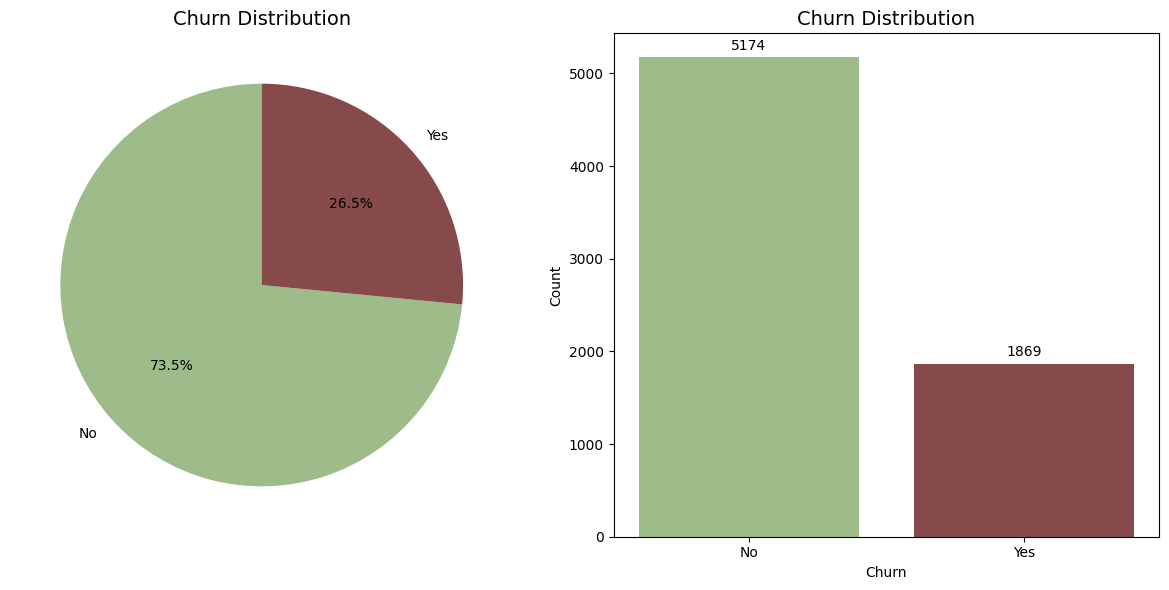

In [22]:
churn_counts = df['Churn'].value_counts()

# Colors mapping
colors = {'Yes': '#874A4A', 'No': '#9EBC8A'}

# Create subplot (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart
axes[0].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors[label] for label in churn_counts.index]
)
axes[0].set_title('Churn Distribution', fontsize=14)

# Bar chart
bars = axes[1].bar(
    churn_counts.index,
    churn_counts.values,
    color=[colors[label] for label in churn_counts.index]
)

# Add numeric labels on top of bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + (0.01 * max(churn_counts.values)),  # a bit above the bar
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10
    )

axes[1].set_title('Churn Distribution', fontsize=14)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Churn')

# Adjust layout
plt.tight_layout()
plt.show()

In [23]:
def pie_chart(df, columns, autopct='%1.1f%%'):
    # Define custom palette
    custom_palette = ['#73946B', '#9EBC8A', '#DDEB9D', '#F8ED8C', '#F9C784', '#FCAF58', '#F98948']

    num_cols = 3  # number of charts per row
    num_rows = int(np.ceil(len(columns) / num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        value_counts = df[column].value_counts()

        # Repeat colors if number of categories exceeds palette length
        colors = (custom_palette * ((len(value_counts) // len(custom_palette)) + 1))[:len(value_counts)]

        axes[i].pie(
            value_counts,
            labels=value_counts.index,
            autopct=autopct,
            startangle=90,
            colors=colors
        )
        axes[i].set_title(f"Distribution of {column}", fontsize=12)
        axes[i].axis('equal')

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

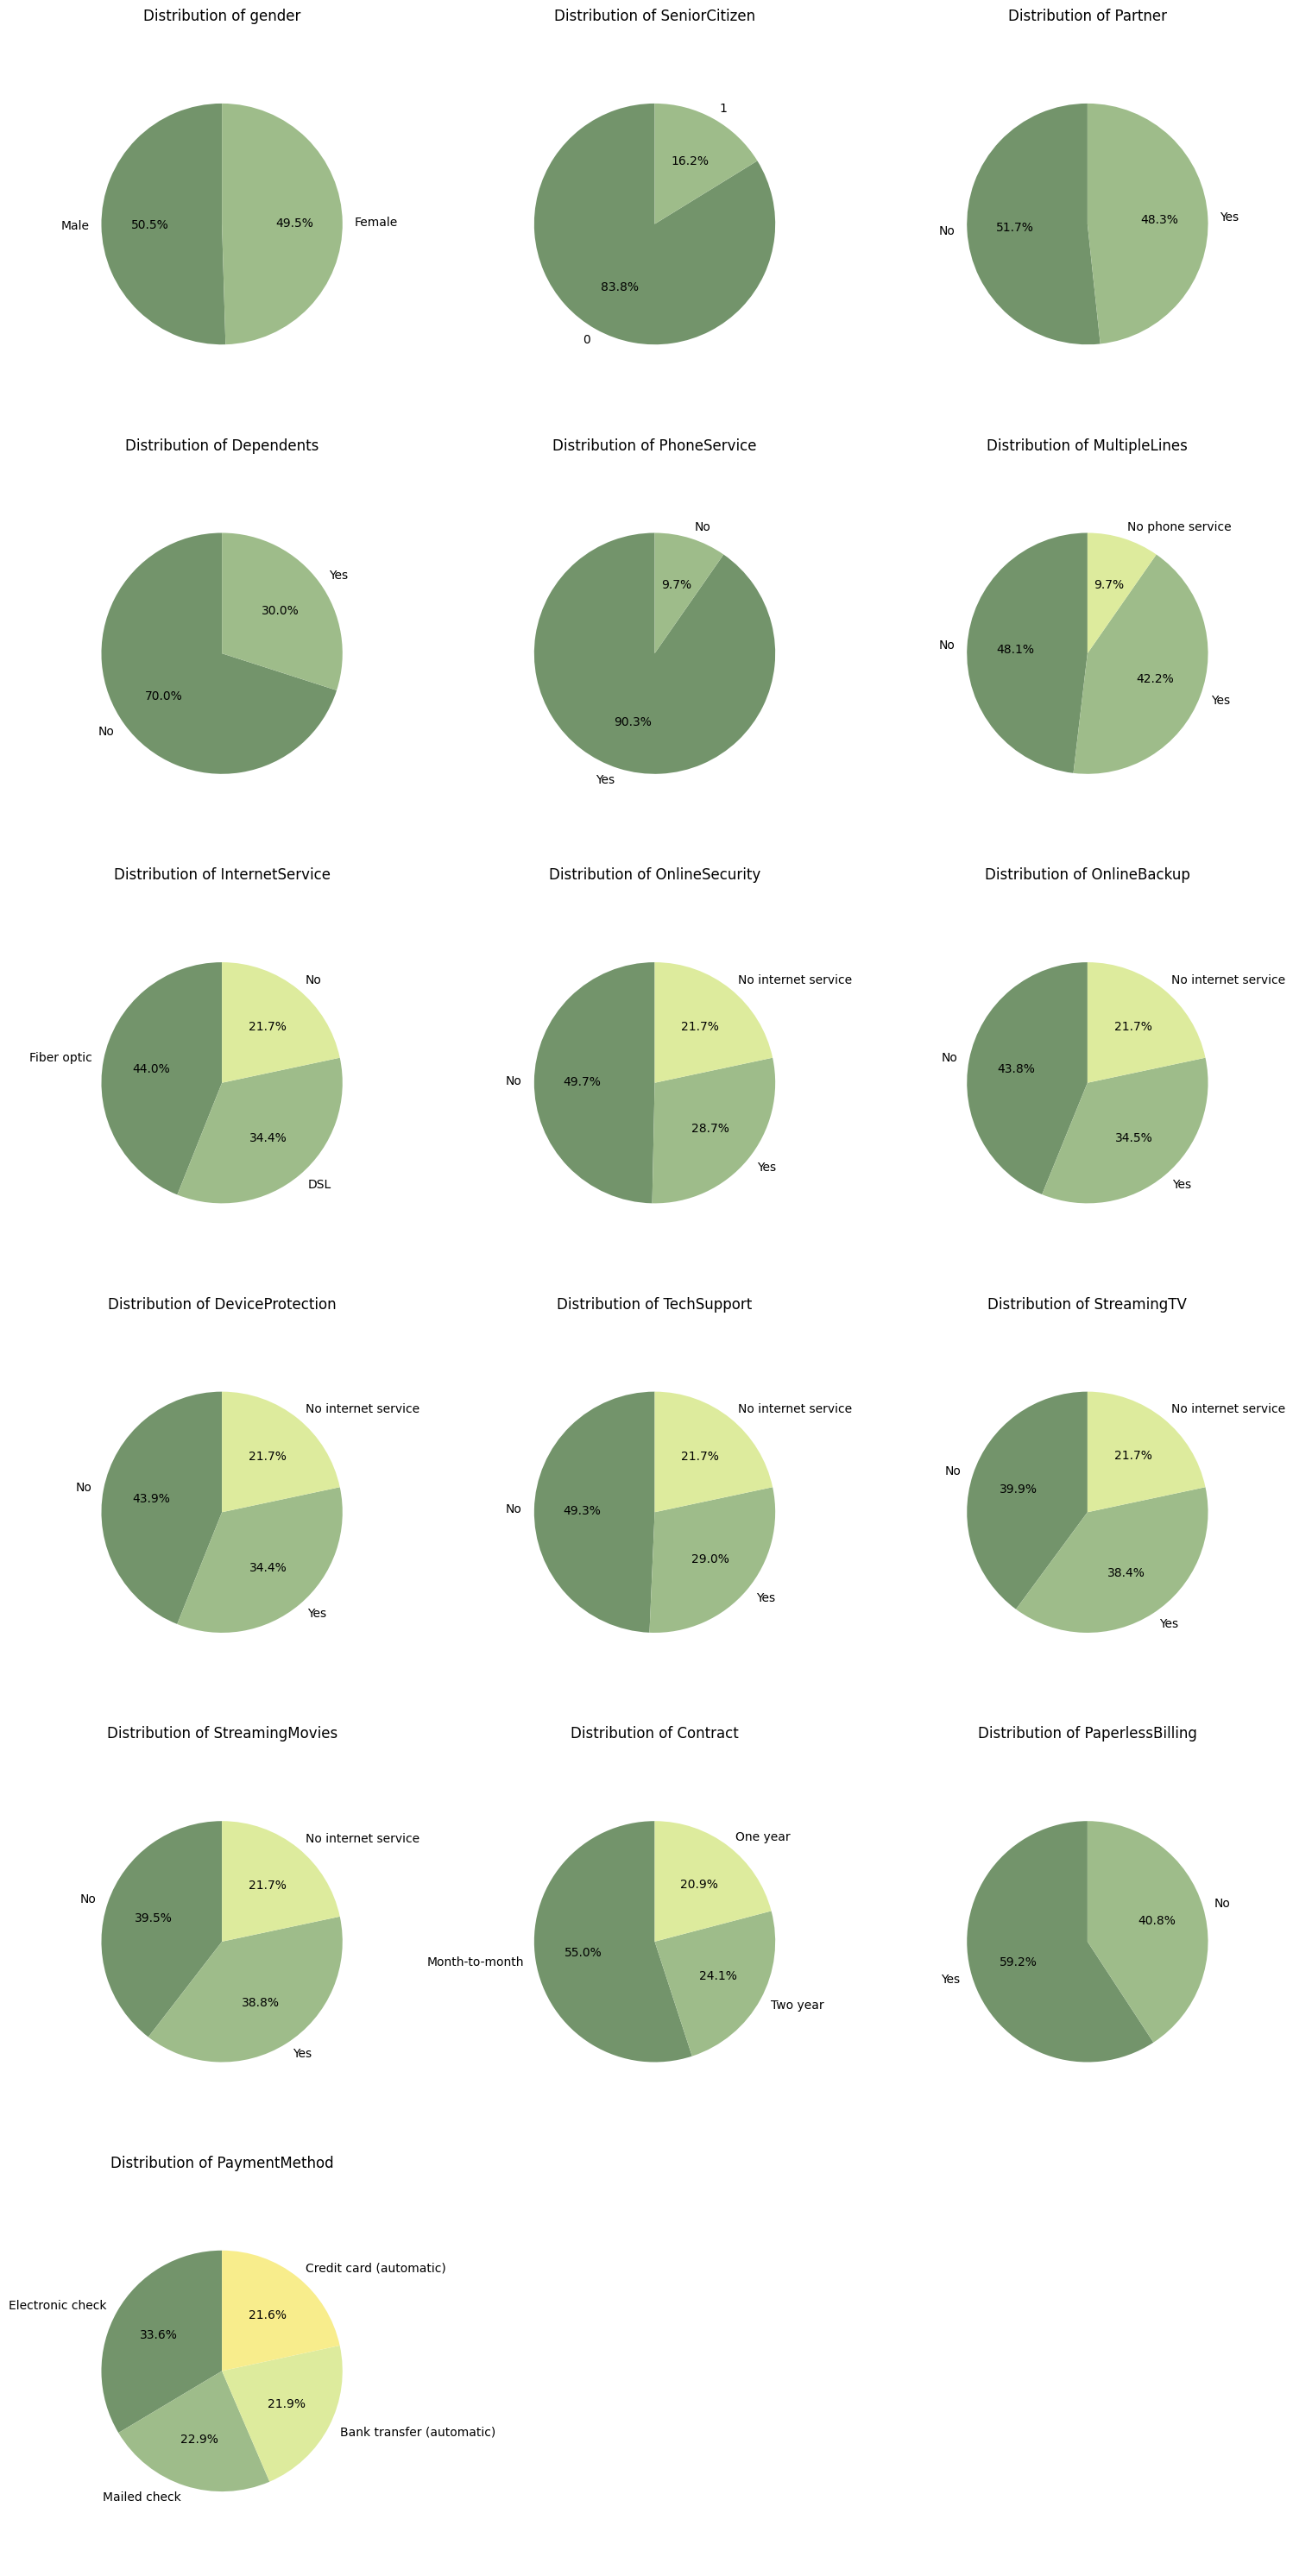

In [24]:
pie_chart(df, cat_cols)

In [25]:
def bar_chart(df, columns):
    # Custom palette
    custom_palette = ['#73946B', '#9EBC8A', '#DDEB9D',
                      '#F8ED8C', '#F9C784', '#FCAF58', '#F98948']

    num_cols = 3  # charts per row
    num_rows = int(np.ceil(len(columns) / num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        value_counts = df[column].value_counts()  # bisa ganti ke .sort_index() kalau mau urut kategori

        # Repeat colors if categories > palette length
        colors = (custom_palette * ((len(value_counts) // len(custom_palette)) + 1))[:len(value_counts)]

        bars = axes[i].bar(value_counts.index, value_counts.values, color=colors)

        # Add white bold labels on top of bars
        for bar in bars:
            height = bar.get_height()
            axes[i].text(
                bar.get_x() + bar.get_width() / 2,
                height + (0.02 * height),  # kasih jarak 2% dari tinggi bar
                f'{int(height)}',
                ha='center', va='bottom',
                fontsize=10, color='black'
            )

        axes[i].set_title(f"Distribution of {column}", fontsize=12)
        axes[i].set_ylim(0, max(value_counts.values) * 1.1)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis='x', rotation=45)

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

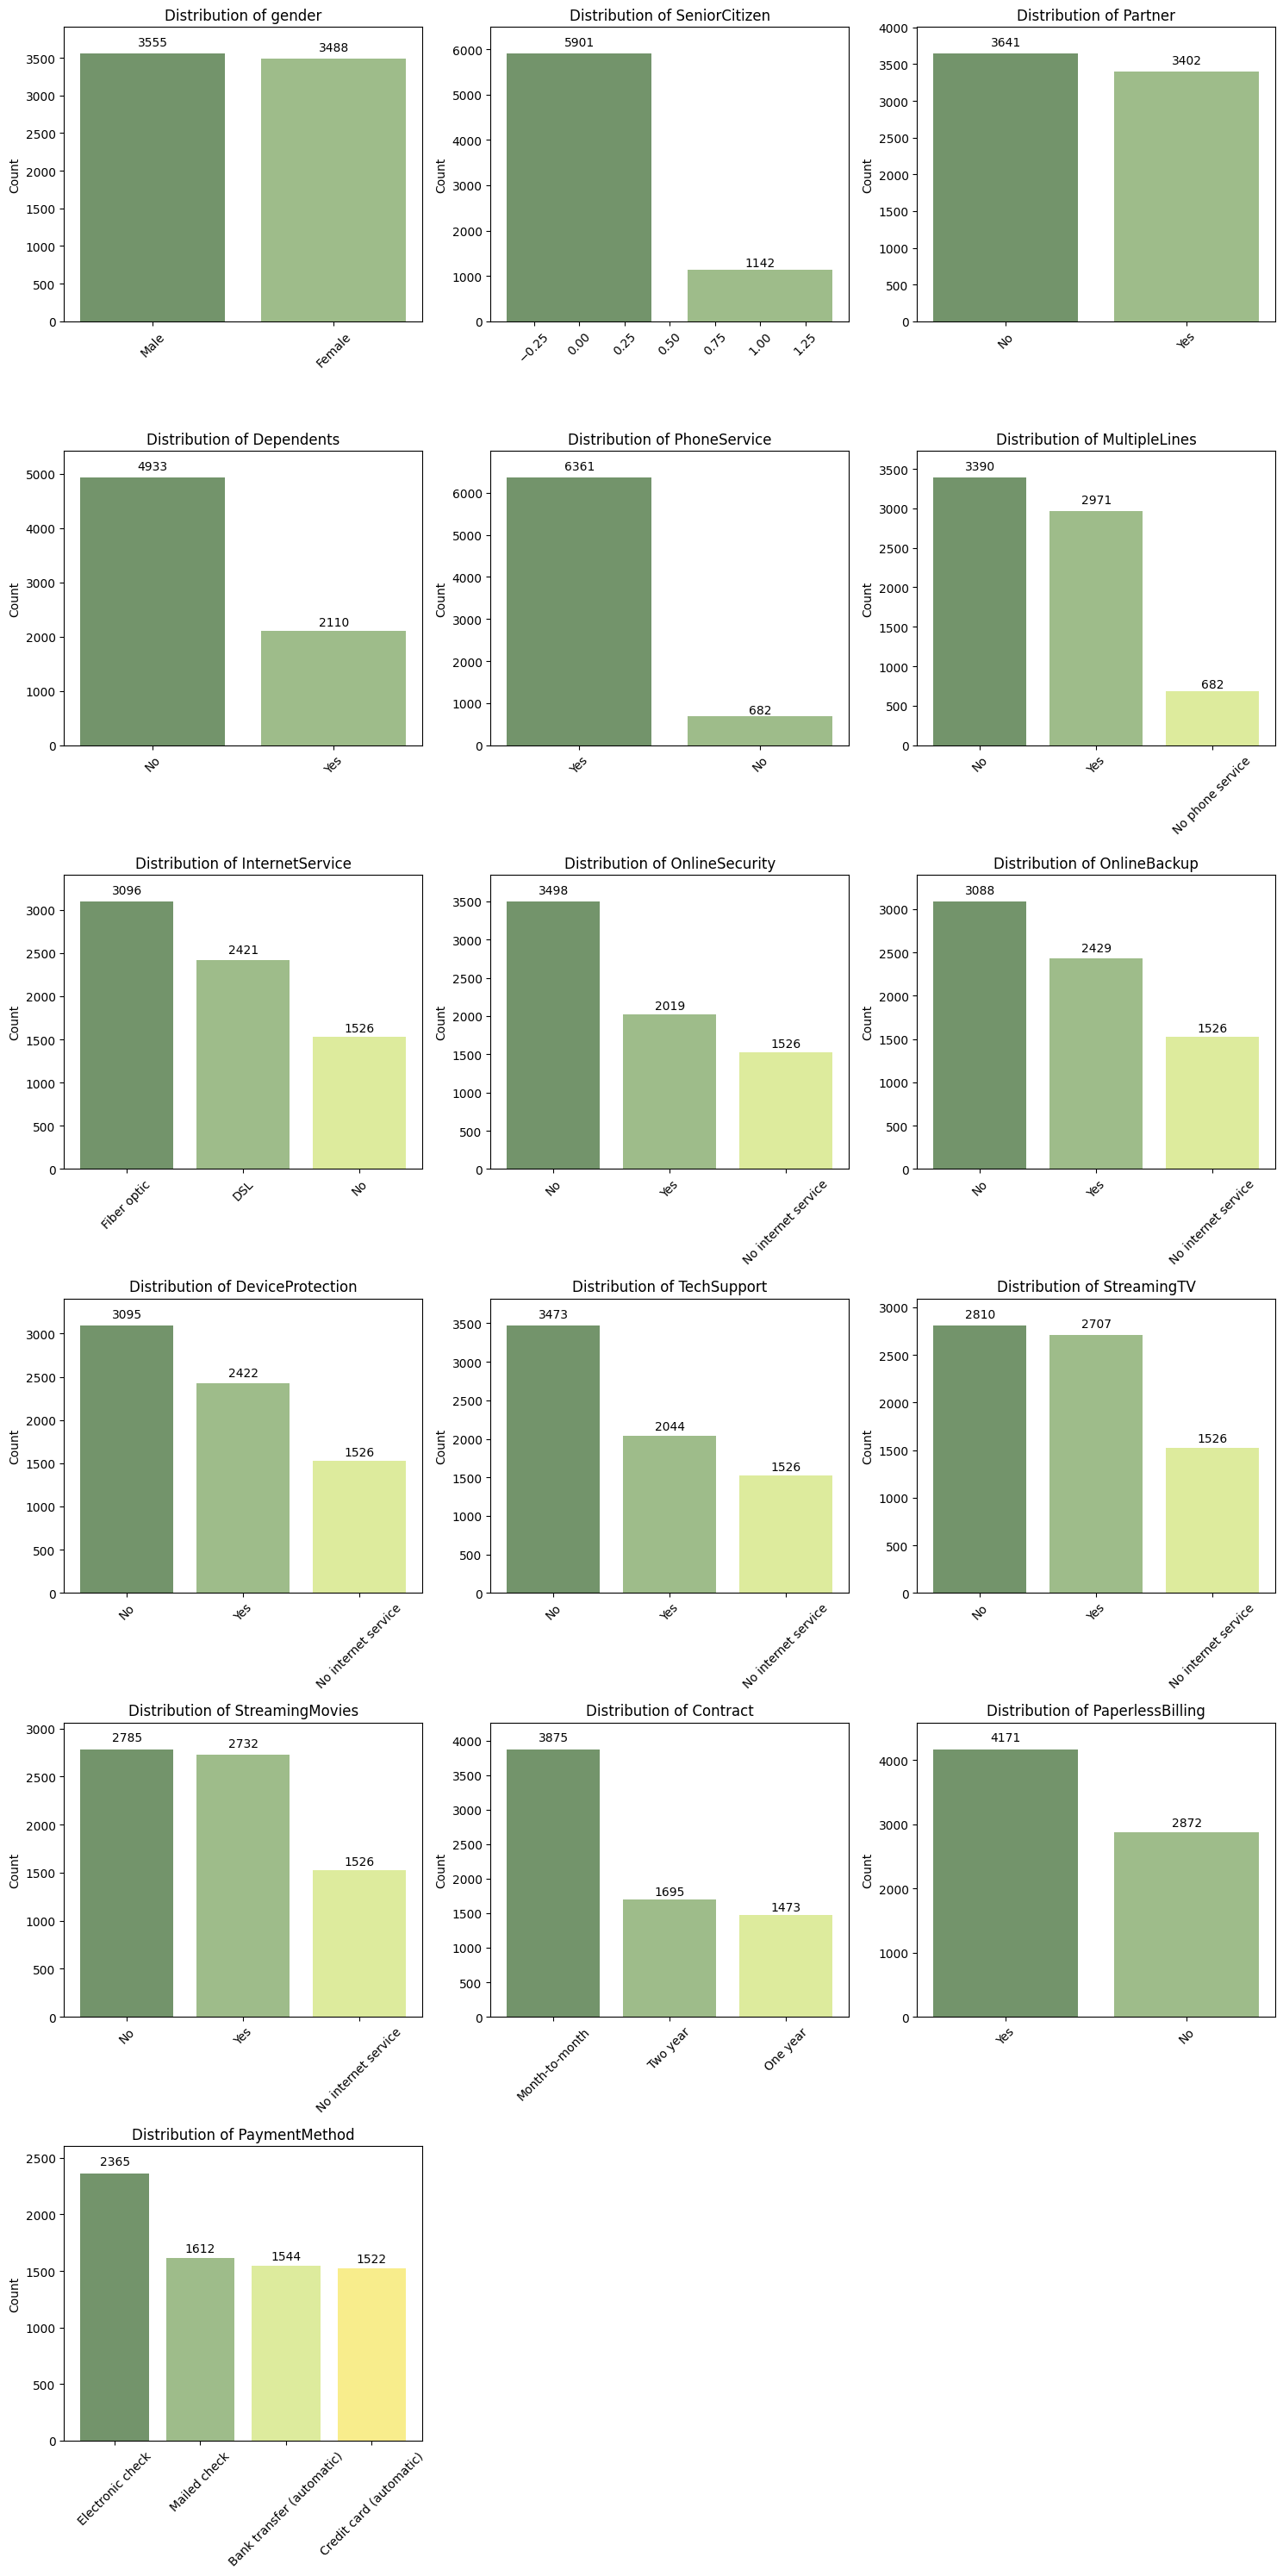

In [26]:
bar_chart(df, cat_cols)

In [27]:
cat_cols_bivariate = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                      'Contract', 'PaperlessBilling', 'PaymentMethod']

In [28]:
def barchart_stacked(df, features, feature1='Churn'):
    colors = {'Yes': '#ce5454', 'No': '#9EBC8A'}

    ncols = 2
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5*nrows))
    axes = axes.flatten()

    for i, feature2 in enumerate(features):
        ax = axes[i]

        # Prepare stacked data
        data = df.groupby([feature2, feature1]).size().reset_index(name='count')
        pivot_data = data.pivot(index=feature2, columns=feature1, values='count').fillna(0)

        # Plot stacked bars
        bottom_vals = np.zeros(len(pivot_data))
        for churn_status in colors.keys():
            ax.bar(
                pivot_data.index,
                pivot_data[churn_status],
                bottom=bottom_vals,
                color=colors[churn_status],
                label=churn_status
            )
            # Add number inside each segment
            for idx, val in enumerate(pivot_data[churn_status]):
                if val > 0:
                    ax.text(
                        idx,
                        bottom_vals[idx] + val/2,
                        f"{int(val)}",
                        ha='center', va='center',
                        color='white', fontsize=10
                    )
            bottom_vals += pivot_data[churn_status]

        # Add total number on top
        for idx, total in enumerate(bottom_vals):
            ax.text(
                idx,
                total + (max(bottom_vals) * 0.02),
                f"{int(total)}",
                ha='center', va='bottom',
                fontsize=10
            )

        ax.set_title(f'{feature2} vs {feature1}')
        ax.set_xlabel(feature2)
        ax.set_ylabel('Number of Customers')
        ax.set_ylim(0, max(bottom_vals) * 1.15)

        # Rotate x-axis labels
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

        # Move legend outside plot
        ax.legend(title=feature1, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Remove empty axes
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

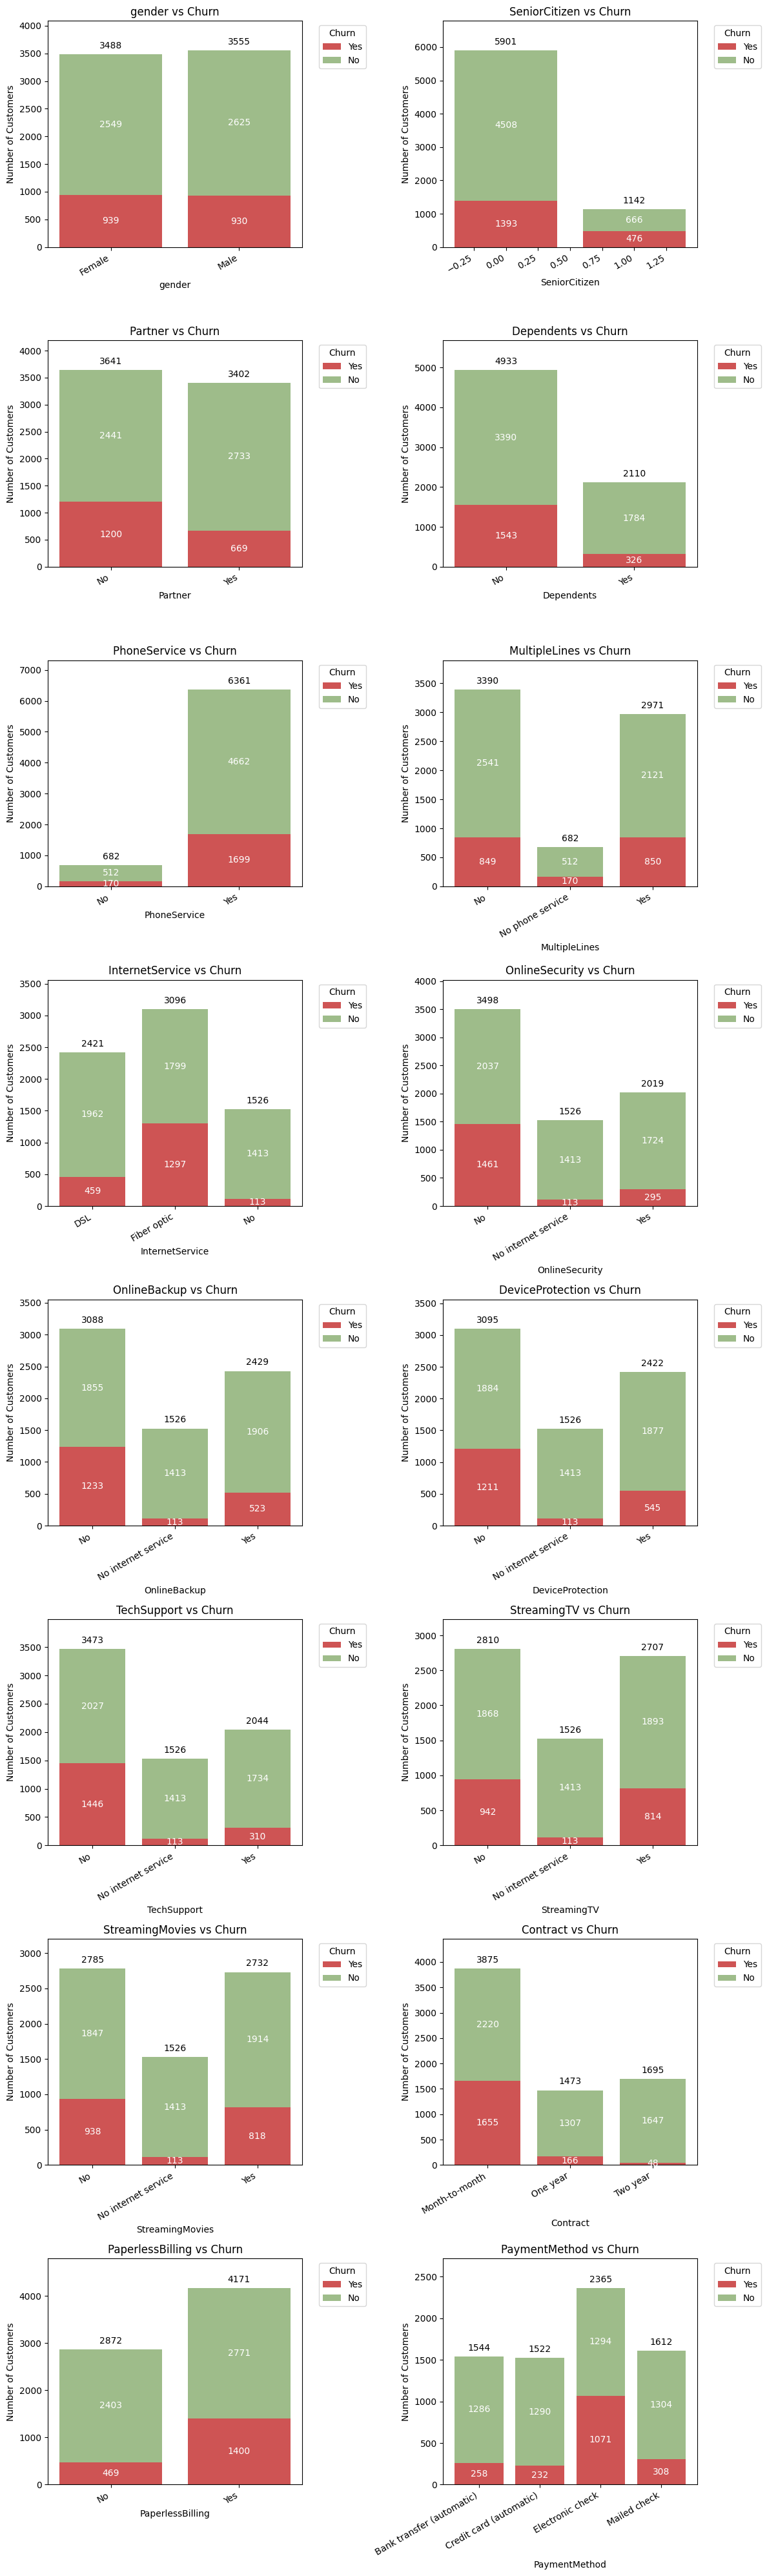

In [29]:
barchart_stacked(df, cat_cols_bivariate)

In [30]:
def barchart_bivariate(df, features, feature1='Churn'):
    colors = {'Yes': '#ce5454', 'No': '#9EBC8A'}

    ncols = 2
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5*nrows))
    axes = axes.flatten()

    for i, feature2 in enumerate(features):
        ax = axes[i]

        # Calculate counts
        data = df.groupby([feature2, feature1]).size().reset_index(name='count')

        # Create barplot
        sns.barplot(
            data=data,
            x=feature2,
            y='count',
            hue=feature1,
            palette=colors,
            ax=ax
        )

        # Add numeric labels on top of bars
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom',
                xytext=(0, 6),  # distance from top of bar
                textcoords='offset points',
                color='black', fontsize=11
            )

        ax.set_title(f'{feature2} vs {feature1}')
        ax.set_xlabel(feature2)
        ax.set_ylabel('Number of Customers')
        ax.set_ylim(0, max(data['count']) * 1.15)

        # Rotate x-axis labels
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

        # Move legend outside the plot
        ax.legend(title=feature1, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Remove empty axes if number of features is less than the grid slots
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

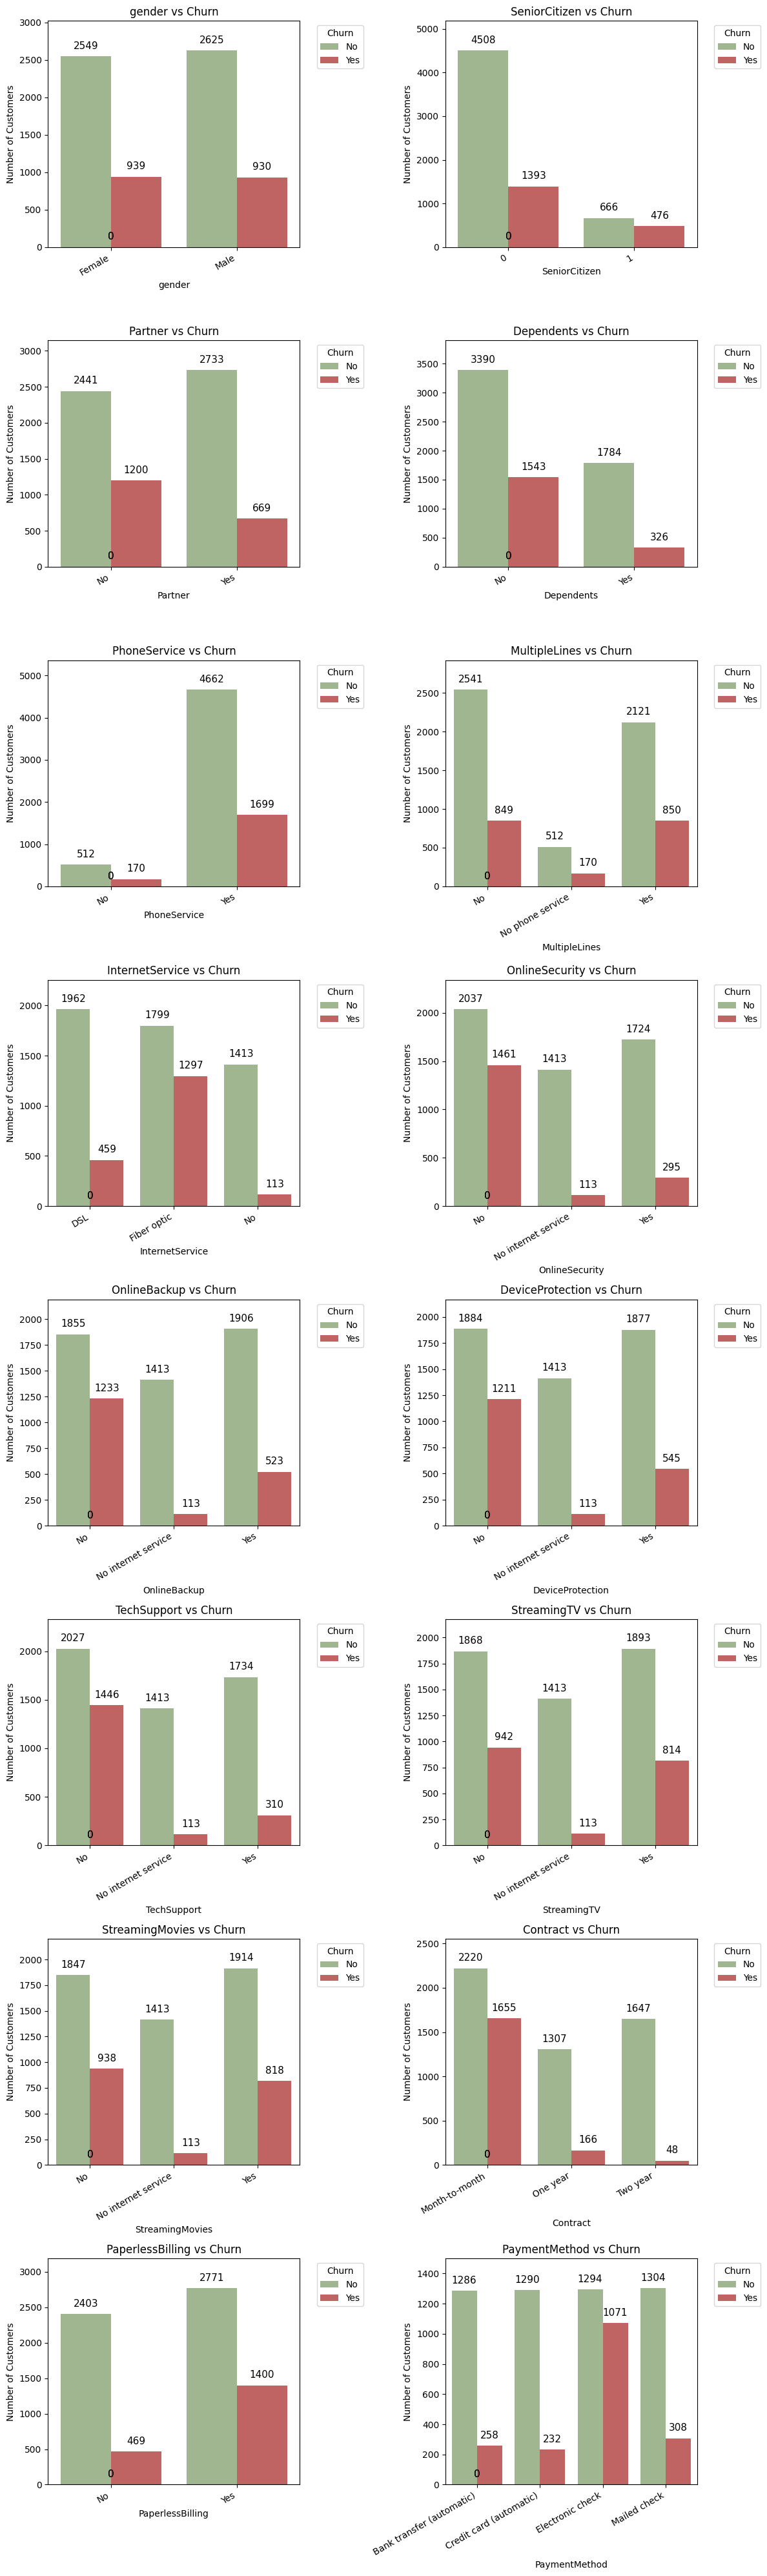

In [31]:
barchart_bivariate(df, cat_cols_bivariate)

In [32]:
def displot(df, features, feature1='Churn'):
    n_features = len(features)
    ncols = 1
    nrows = (n_features + 1) // 1

    plt.figure(figsize=(12, 5*nrows))

    # Warna untuk kelas churn
    palette = {
        'Yes': '#ce5454',    # Not Churn
        'No' : '#9EBC8A'    # Churn
    }

    for i, feature2 in enumerate(features, 1):
        plt.subplot(nrows, ncols, i)

        for cls in df[feature1].unique():
            subset = df[df[feature1] == cls]
            sns.kdeplot(subset[feature2],
                        shade=True,
                        alpha=0.5,
                        color=palette[cls],
                        label='Churn' if cls == 'Yes' else 'Not Churn')

        plt.title(f'{feature2} vs {feature1}')
        plt.xlabel(feature2)
        plt.ylabel('Density')
        plt.legend()

    plt.tight_layout()
    plt.show()

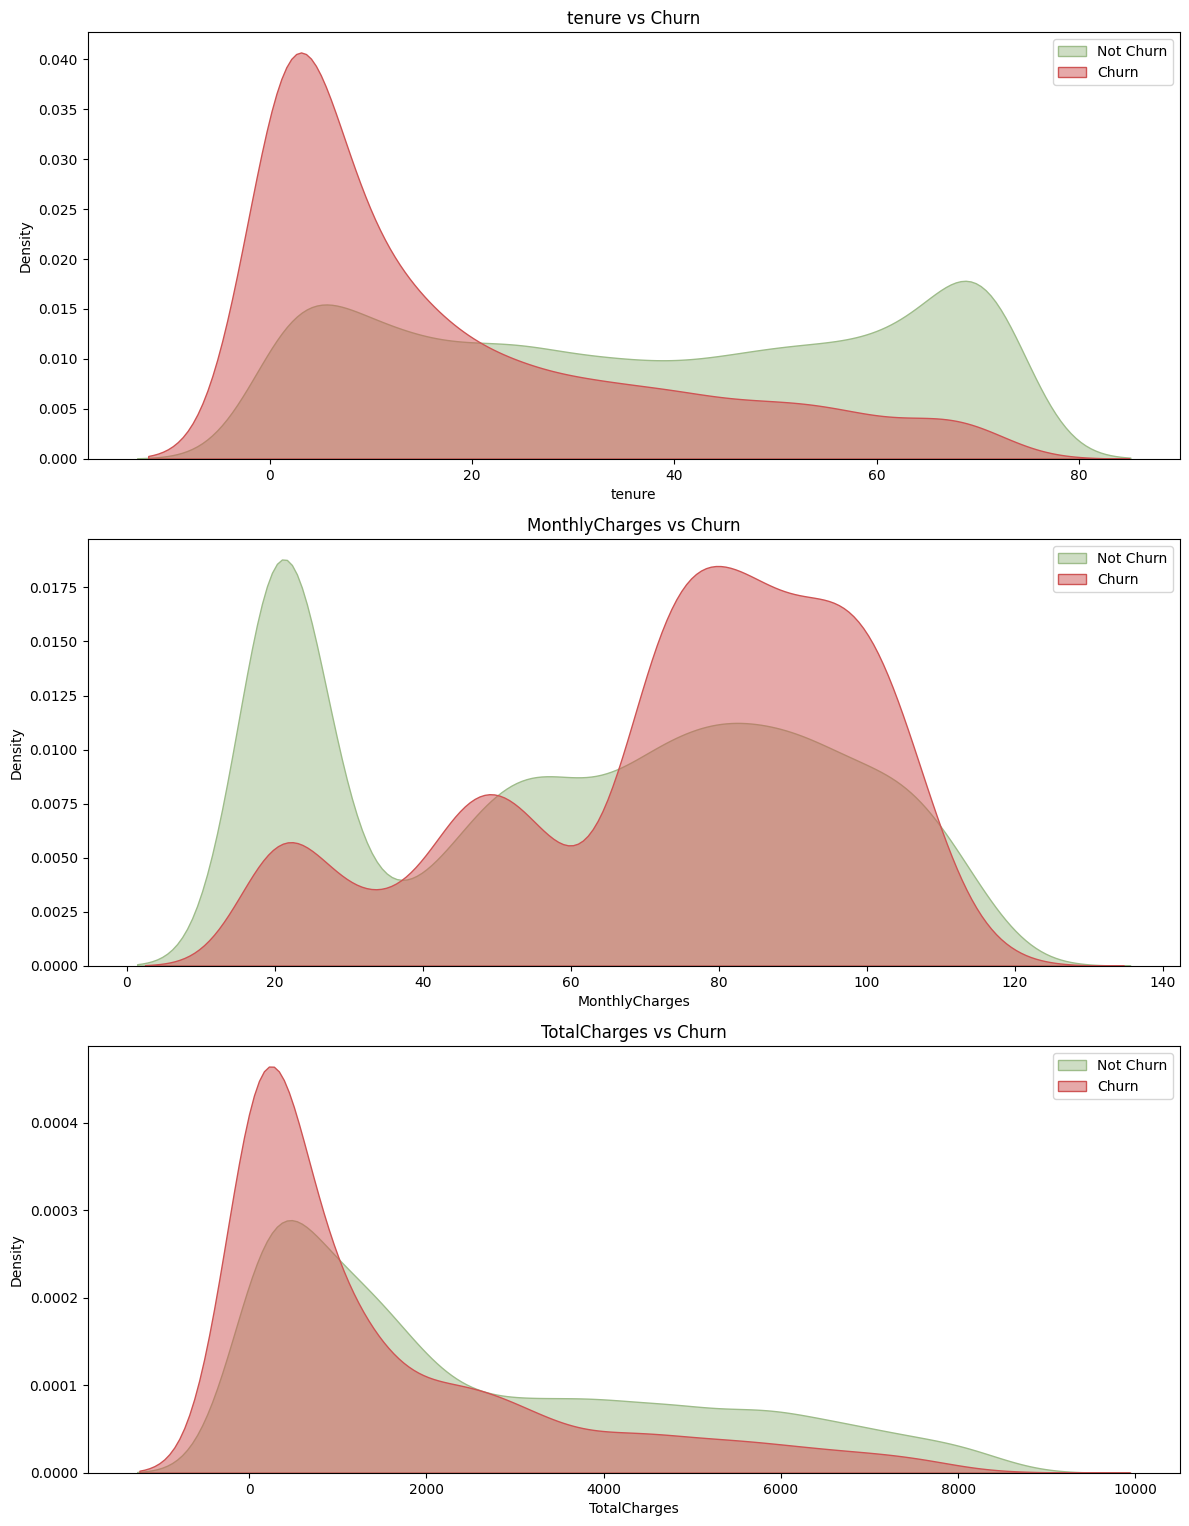

In [33]:
displot(df, num_cols)

In [34]:
# Drop customerID since it's just an identifier
df_encoded = cust.drop('customerID', axis=1)

# Convert TotalCharges to numeric in case there are spaces
df_encoded['TotalCharges'] = pd.to_numeric(df_encoded['TotalCharges'], errors='coerce')

# Identify categorical columns (dtype == object)
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# Apply Label Encoding for categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Now df_encoded is fully numeric and ready for correlation
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


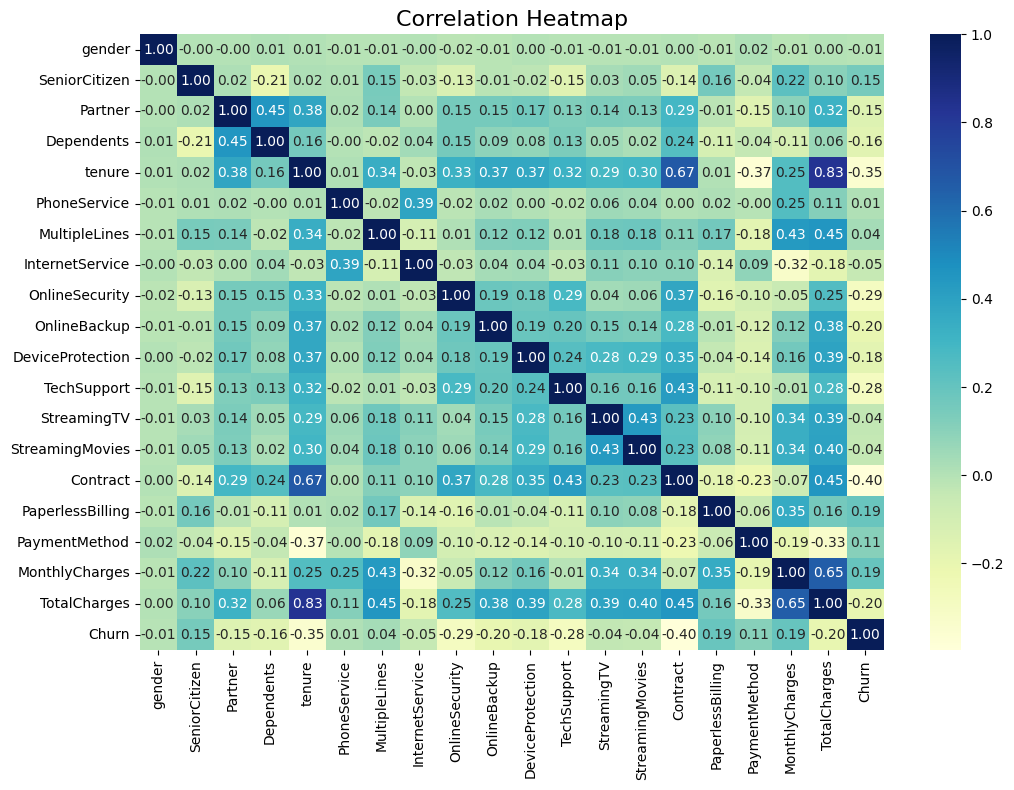

In [35]:
# correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [38]:
df_df = df.copy()

In [39]:
# Drop 'customerID' because it's not a feature but a unique ID
df_df = df_df.drop(columns=['customerID'])

In [40]:
# Encode target 'Churn' into 0/1
df_df['Churn'] = df_df['Churn'].map({'No': 0, 'Yes': 1})

In [41]:
# Binary categorical columns — use LabelEncoder
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']
for col in binary_cols:
    # SeniorCitizen is already 0/1 but check for consistency
    if df_df[col].dtype == 'object':
        df_df[col] = LabelEncoder().fit_transform(df_df[col])

In [42]:
# Multi-category categorical columns — use One-Hot Encoding
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']

# Apply One-Hot Encoding, drop_first=True to avoid dummy variable trap
df_df = pd.get_dummies(df_df, columns=multi_cat_cols, drop_first=True)

In [43]:
# Numerical columns to scale
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [44]:
# Convert TotalCharges to numeric (sometimes stored as string)
df_cust['TotalCharges'] = pd.to_numeric(df_cust['TotalCharges'], errors='coerce')

In [45]:
# Fill missing TotalCharges with median value
df_cust['TotalCharges'] = df_cust['TotalCharges'].fillna(df_cust['TotalCharges'].median())

In [47]:
# Scale numerical features using StandardScaler (mean=0, std=1)
scaler = StandardScaler()
df_df[num_cols] = scaler.fit_transform(df_df[num_cols])

df_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.992611,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.066327,1,0,-0.259629,-0.172165,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.958066,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.514251,0,0,-0.746535,-0.193672,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.236724,1,1,0.197365,-0.938874,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [48]:
# Assuming df is your preprocessed dataframe
X = df_df.drop(columns=['Churn'])
y = df_df['Churn']

# Split data: 80% train, 20% test, stratify to keep churn ratio consistent
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
# Initialize Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)

# Train model
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

In [50]:
# create probabilities prediction class 1 (churn)
proba = rf.predict_proba(X_test)[:, 1]

# create merged dataframe
result_df = X_test.copy()
result_df['Actual_Churn'] = y_test.values
result_df['Prediction'] = y_pred
result_df['Probability'] = proba

# show data
result_df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Prediction,Probability
437,1,0,1,1,1.613701,1,1,1.638143,2.730245,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,0,0,0.00
2280,0,1,0,0,-0.992402,1,1,1.176164,-0.604943,False,True,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,True,False,False,0,1,0.80
2235,0,0,1,1,0.351370,1,1,0.451620,0.410947,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False,False,0,0,0.10
4460,1,0,1,0,-0.585198,1,0,0.446635,-0.357792,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,0,0,0.26
3761,0,0,1,0,1.613701,1,1,0.594535,1.605736,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,True,False,True,True,False,False,0,0,0.00
5748,0,0,0,0,-0.463037,1,1,1.166193,-0.126701,False,True,True,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,0,0,0.30
3568,0,0,0,0,-0.463037,1,1,1.142928,-0.142650,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,True,False,False,False,False,False,0,0,0.40
2976,1,0,0,1,-0.544478,1,1,-1.351430,-0.812012,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,False,True,False,False,0,0,0.03
5928,0,0,1,1,1.165777,1,0,-1.496006,-0.427124,False,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,True,False,False,0,0,0.02
1639,1,1,0,0,-0.625919,1,1,-0.655137,-0.665804,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,1,1,0.52


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

Confusion Matrix:


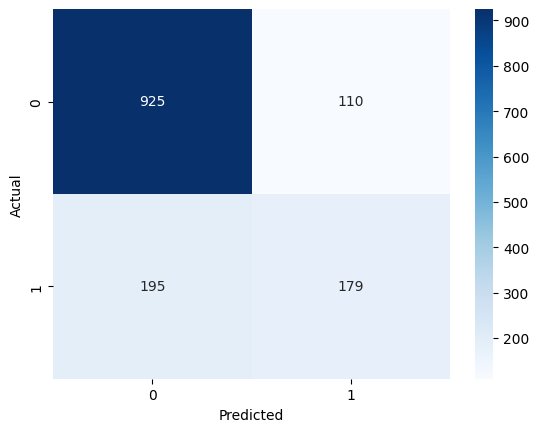

In [51]:
# Evaluate performance
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [52]:
# Feature importance
importances = rf.feature_importances_
features = X.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

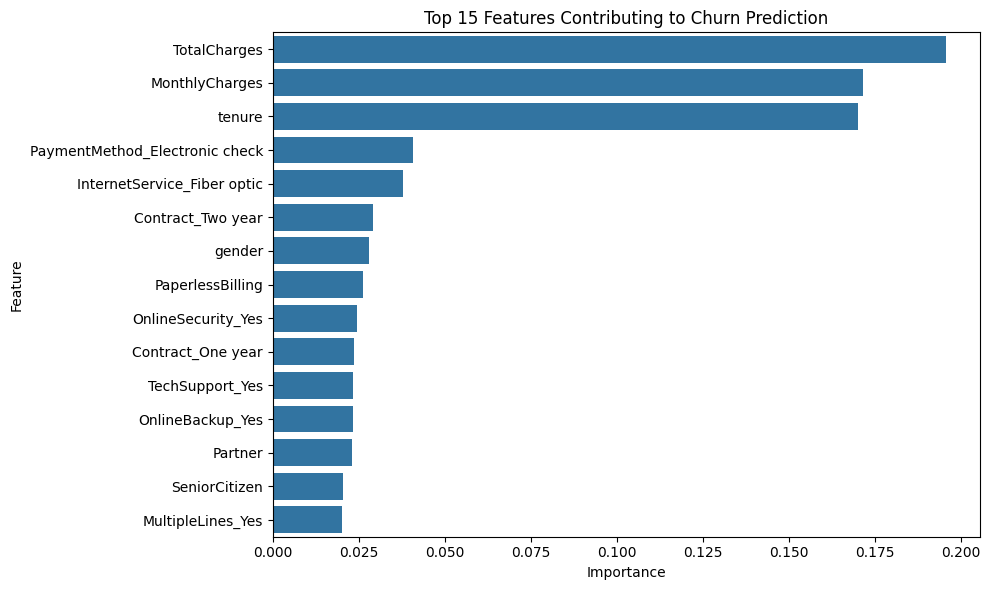

In [53]:
# Plot top 15 important features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15))
plt.title('Top 15 Features Contributing to Churn Prediction')
plt.tight_layout()
plt.show()

ROC-AUC: 0.823


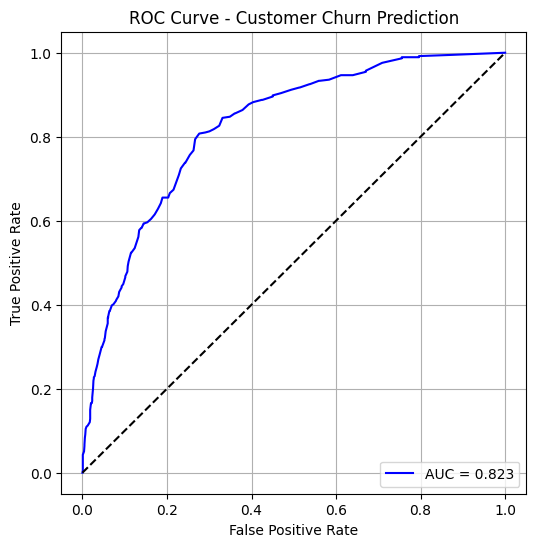

In [54]:
from sklearn.metrics import roc_auc_score, roc_curve

# Calculate ROC-AUC
auc = roc_auc_score(y_test, proba)
print(f"ROC-AUC: {auc:.3f}")

# Create ROC curve
fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='blue')
plt.plot([0, 1], [0, 1], 'k--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()